# Insurance Claim Risk & Premium Predictor

## Project Objective

This project aims to develop machine learning models for analyzing insurance customer data and predicting two key outcomes:

1. Insurance premium amount using a regression model.
2. Claim risk using a classification model.

The project involves data generation, exploratory data analysis, preprocessing, model training, and evaluation using appropriate machine learning metrics.

## Dataset

The dataset used in this project is a synthetically generated insurance customer dataset.

It contains information about insurance customers, their demographics, health and lifestyle factors, policy details, and claim history.

The dataset is used for two machine learning tasks:

- **Regression:** Predict the insurance premium amount.
- **Classification:** Predict whether a customer is at high risk of making an insurance claim.

### Data Generation

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 2000

data = {
    "age": np.random.randint(18, 71, n_samples),
    "bmi": np.round(np.random.uniform(18.5, 40.0, n_samples), 1),
    "dependents": np.random.randint(0, 5, n_samples),
    "smoker": np.random.choice(["Yes", "No"], n_samples, p=[0.2, 0.8]),
    "policy_type": np.random.choice(
        ["Basic", "Standard", "Comprehensive"],
        n_samples,
        p=[0.3, 0.5, 0.2]
    ),
    "claim_history": np.random.randint(0, 5, n_samples),
    "annual_income": np.random.randint(200000, 2000001, n_samples),
    "coverage_amount": np.random.randint(500000, 5000001, n_samples)
}

df = pd.DataFrame(data)

In [2]:
df.head()

,age,bmi,dependents,smoker,policy_type,claim_history,annual_income,coverage_amount
0,56,38.9,1,No,Standard,3,1818755,651521
1,69,21.7,0,No,Standard,1,246901,2376213
2,46,27.8,0,No,Standard,4,1725304,4690198
3,32,38.8,2,No,Basic,2,566056,3131866
4,60,27.5,1,No,Standard,1,795350,3046946


In [3]:
risk_score = (
    0.025 * df["age"]
    + 0.06 * df["bmi"]
    + 0.7 * df["claim_history"]
    + 1.2 * (df["smoker"] == "Yes")
    + 0.3 * df["dependents"]
)

risk_probability = 1 / (1 + np.exp(-(risk_score - 5.5)))

df["claim_risk"] = np.random.binomial(1, risk_probability)

In [4]:
df["claim_risk"].value_counts()

claim_risk
0    1118
1     882
Name: count, dtype: int64

In [5]:
base_premium = (
    5000
    + 120 * df["age"]
    + 250 * df["bmi"]
    + 1500 * df["claim_history"]
    + 8000 * (df["smoker"] == "Yes")
    + 0.01 * df["coverage_amount"]
    + 0.001 * df["annual_income"]
)

policy_factor = df["policy_type"].map({
    "Basic": 0.8,
    "Standard": 1.0,
    "Comprehensive": 1.3
})

df["premium_amount"] = np.round(
    base_premium * policy_factor + np.random.normal(0, 3000, n_samples),
    2
)

In [6]:
df.head()

,age,bmi,dependents,smoker,policy_type,claim_history,annual_income,coverage_amount,claim_risk,premium_amount
0,56,38.9,1,No,Standard,3,1818755,651521,1,33181.19
1,69,21.7,0,No,Standard,1,246901,2376213,0,40770.68
2,46,27.8,0,No,Standard,4,1725304,4690198,0,76464.27
3,32,38.8,2,No,Basic,2,566056,3131866,1,41582.23
4,60,27.5,1,No,Standard,1,795350,3046946,1,46261.66


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              2000 non-null   int32  
 1   bmi              2000 non-null   float64
 2   dependents       2000 non-null   int32  
 3   smoker           2000 non-null   str    
 4   policy_type      2000 non-null   str    
 5   claim_history    2000 non-null   int32  
 6   annual_income    2000 non-null   int32  
 7   coverage_amount  2000 non-null   int32  
 8   claim_risk       2000 non-null   int32  
 9   premium_amount   2000 non-null   float64
dtypes: float64(2), int32(6), str(2)
memory usage: 109.5 KB


In [8]:
df.describe()

,age,bmi,dependents,claim_history,annual_income,coverage_amount,claim_risk,premium_amount
count,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03,2.000000e+03,2000.000000,2000.000000
mean,44.376500,29.238250,2.022500,2.014500,1.100547e+06,2.791006e+06,0.441000,51534.069060
std,15.226644,6.217421,1.408185,1.418907,5.189171e+05,1.321126e+06,0.496631,16894.082869
min,18.000000,18.500000,0.000000,0.000000,2.009030e+05,5.016580e+05,0.000000,13860.460000
25%,31.000000,23.900000,1.000000,1.000000,6.598282e+05,1.652362e+06,0.000000,38979.317500
50%,45.000000,29.300000,2.000000,2.000000,1.099963e+06,2.832750e+06,0.000000,49896.765000
75%,57.000000,34.500000,3.000000,3.000000,1.551145e+06,3.957255e+06,1.000000,62345.390000
max,70.000000,40.000000,4.000000,4.000000,1.999995e+06,4.999435e+06,1.000000,101554.700000


In [9]:
df.to_csv("insurance_claim_data.csv", index=False)

In [10]:
df.shape

(2000, 10)

## Exploratory Data Analysis

### Understanding the Dataset

In [41]:
df.head()

,age,bmi,dependents,smoker,policy_type,claim_history,annual_income,coverage_amount,claim_risk,premium_amount
0,56,38.9,1,No,Standard,3,1818755,651521,1,33181.19
1,69,21.7,0,No,Standard,1,246901,2376213,0,40770.68
2,46,27.8,0,No,Standard,4,1725304,4690198,0,76464.27
3,32,38.8,2,No,Basic,2,566056,3131866,1,41582.23
4,60,27.5,1,No,Standard,1,795350,3046946,1,46261.66


In [42]:
df.shape

(2000, 10)

In [43]:
df.columns

Index(['age', 'bmi', 'dependents', 'smoker', 'policy_type', 'claim_history',
       'annual_income', 'coverage_amount', 'claim_risk', 'premium_amount'],
      dtype='str')

### Distribution of Categorical Variables

In [44]:
df['smoker'].value_counts()

smoker
No     1598
Yes     402
Name: count, dtype: int64

In [45]:
df['policy_type'].value_counts()

policy_type
Standard         994
Basic            584
Comprehensive    422
Name: count, dtype: int64

In [46]:
df['claim_risk'].value_counts()

claim_risk
0    1118
1     882
Name: count, dtype: int64

In [47]:
df['claim_history'].value_counts().sort_index()

claim_history
0    396
1    405
2    378
3    416
4    405
Name: count, dtype: int64

### Visualizing Policyholder Categories

In [48]:
import matplotlib.pyplot as plt

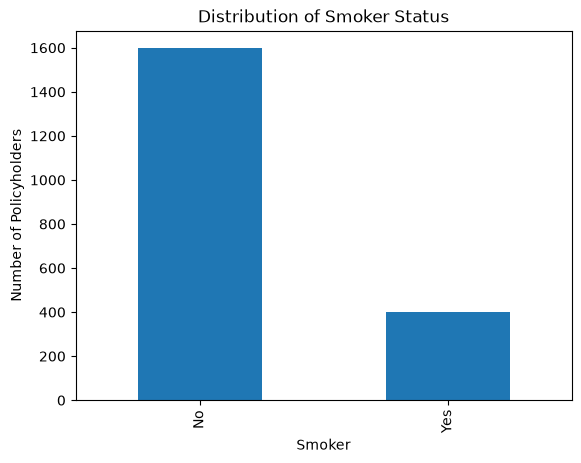

In [49]:
df['smoker'].value_counts().plot(kind='bar')
plt.title('Distribution of Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Number of Policyholders')
plt.show()

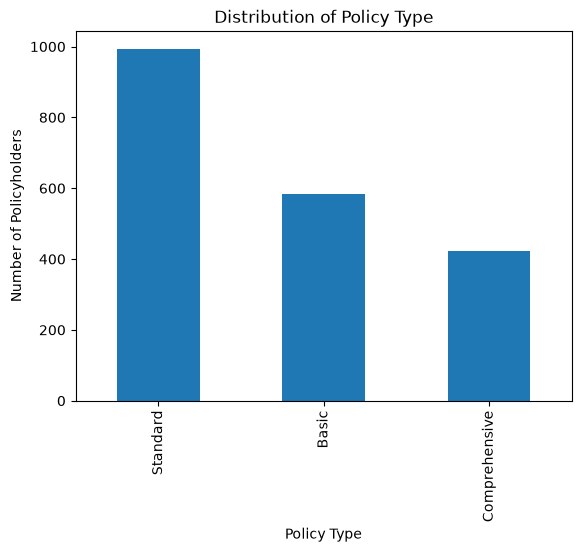

In [50]:
df['policy_type'].value_counts().plot(kind='bar')
plt.title('Distribution of Policy Type')
plt.xlabel('Policy Type')
plt.ylabel('Number of Policyholders')
plt.show()

### Distribution of Numerical Variables

In [51]:
df[['age', 'bmi', 'annual_income', 'coverage_amount', 'premium_amount']].describe()

,age,bmi,annual_income,coverage_amount,premium_amount
count,2000.000000,2000.000000,2.000000e+03,2.000000e+03,2000.000000
mean,44.376500,29.238250,1.100547e+06,2.791006e+06,51534.069060
std,15.226644,6.217421,5.189171e+05,1.321126e+06,16894.082869
min,18.000000,18.500000,2.009030e+05,5.016580e+05,13860.460000
25%,31.000000,23.900000,6.598282e+05,1.652362e+06,38979.317500
50%,45.000000,29.300000,1.099963e+06,2.832750e+06,49896.765000
75%,57.000000,34.500000,1.551145e+06,3.957255e+06,62345.390000
max,70.000000,40.000000,1.999995e+06,4.999435e+06,101554.700000


### Distribution of Key Numerical Variables

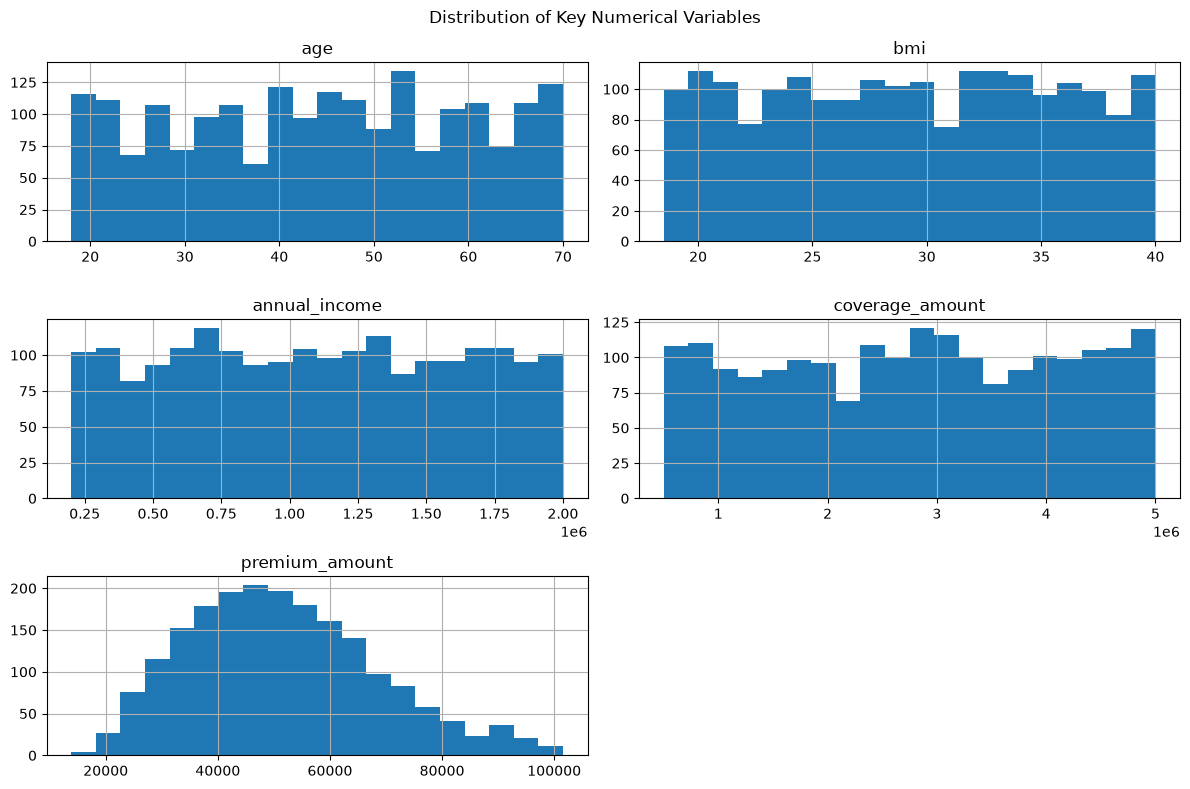

In [52]:
df[['age', 'bmi', 'annual_income', 'coverage_amount', 'premium_amount']].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle('Distribution of Key Numerical Variables')
plt.tight_layout()
plt.show()

### Detecting Potential Outliers

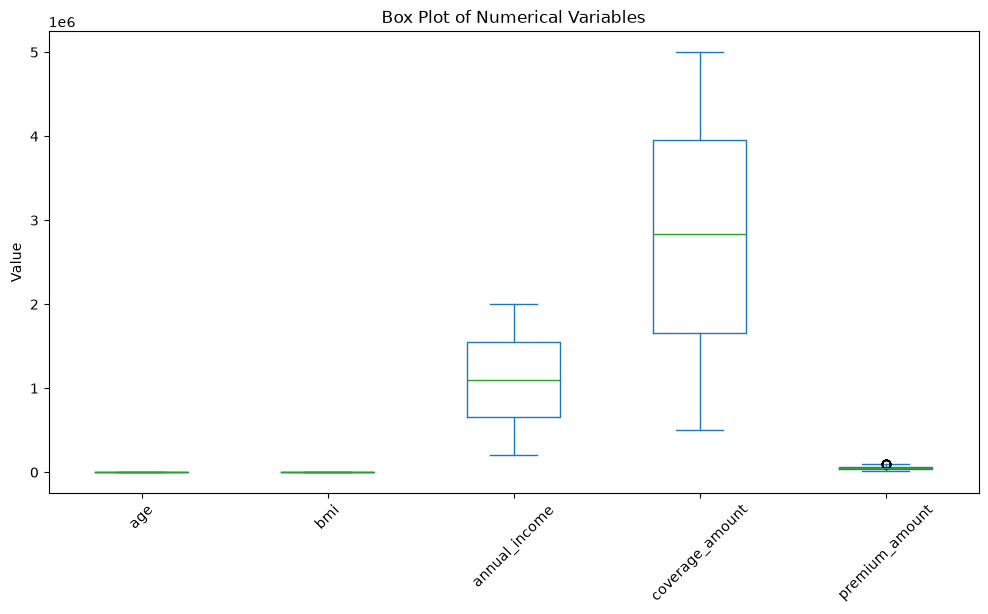

In [53]:
df[['age', 'bmi', 'annual_income', 'coverage_amount', 'premium_amount']].plot(
    kind='box',
    figsize=(12, 6)
)

plt.title('Box Plot of Numerical Variables')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.show()

### Identifying Potential Outliers Using IQR

In [54]:
Q1 = df['premium_amount'].quantile(0.25)
Q3 = df['premium_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 38979.317500000005
Q3: 62345.39
IQR: 23366.072499999995
Lower Bound: 3930.2087500000125
Upper Bound: 97394.49875


In [55]:
potential_outliers = df[
    (df['premium_amount'] < lower_bound) |
    (df['premium_amount'] > upper_bound)
]

print("Number of potential outliers:", len(potential_outliers))

Number of potential outliers: 10


In [56]:
income_outliers = df[
    (df['annual_income'] < 2293.70) |
    (df['annual_income'] > 98335.22)
]

income_outliers[['annual_income']]

,annual_income
0,1818755
1,246901
2,1725304
3,566056
4,795350
...,...
1995,466496
1996,462328
1997,1127888
1998,1525039


In [57]:
income_outliers

,age,bmi,dependents,smoker,policy_type,claim_history,annual_income,coverage_amount,claim_risk,premium_amount
0,56,38.9,1,No,Standard,3,1818755,651521,1,33181.19
1,69,21.7,0,No,Standard,1,246901,2376213,0,40770.68
2,46,27.8,0,No,Standard,4,1725304,4690198,0,76464.27
3,32,38.8,2,No,Basic,2,566056,3131866,1,41582.23
4,60,27.5,1,No,Standard,1,795350,3046946,1,46261.66
...,...,...,...,...,...,...,...,...,...,...
1995,37,21.0,1,No,Basic,1,466496,2620883,0,29673.20
1996,39,22.1,3,No,Standard,1,462328,2735300,1,43139.90
1997,28,18.5,4,Yes,Standard,4,1127888,2336079,1,51749.17
1998,44,34.0,3,No,Standard,2,1525039,1386358,1,40601.65


In [58]:
df['annual_income'].min(), df['annual_income'].max()

(np.int32(200903), np.int32(1999995))

In [59]:
Q1 = df['coverage_amount'].quantile(0.25)
Q3 = df['coverage_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['coverage_amount'] < lower_bound) |
    (df['coverage_amount'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

Q1: 1652362.5
Q3: 3957255.0
IQR: 2304892.5
Lower Bound: -1804976.25
Upper Bound: 7414593.75
Number of potential outliers: 0


In [60]:
Q1 = df['premium_amount'].quantile(0.25)
Q3 = df['premium_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['premium_amount'] < lower_bound) |
    (df['premium_amount'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

Q1: 38979.317500000005
Q3: 62345.39
IQR: 23366.072499999995
Lower Bound: 3930.2087500000125
Upper Bound: 97394.49875
Number of potential outliers: 10


In [61]:
df[['annual_income', 'premium_amount']].head()

,annual_income,premium_amount
0,1818755,33181.19
1,246901,40770.68
2,1725304,76464.27
3,566056,41582.23
4,795350,46261.66


In [62]:
df['annual_income'].equals(df['premium_amount'])

False

In [63]:
df['premium_amount'].describe()

count      2000.000000
mean      51534.069060
std       16894.082869
min       13860.460000
25%       38979.317500
50%       49896.765000
75%       62345.390000
max      101554.700000
Name: premium_amount, dtype: float64

In [64]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['age'] < lower_bound) |
    (df['age'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

Q1: 31.0
Q3: 57.0
IQR: 26.0
Lower Bound: -8.0
Upper Bound: 96.0
Number of potential outliers: 0


In [65]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['bmi'] < lower_bound) |
    (df['bmi'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

Q1: 23.9
Q3: 34.5
IQR: 10.600000000000001
Lower Bound: 7.9999999999999964
Upper Bound: 50.400000000000006
Number of potential outliers: 0


### Distribution of Numerical Variables

Before building machine learning models, it is important to understand how the numerical variables are distributed.

Histograms help us identify:
- The typical range of values
- The spread of the data
- Possible skewness
- Whether extreme values are present

We will examine the distributions of age, BMI, dependents, annual income, coverage amount, and premium amount.

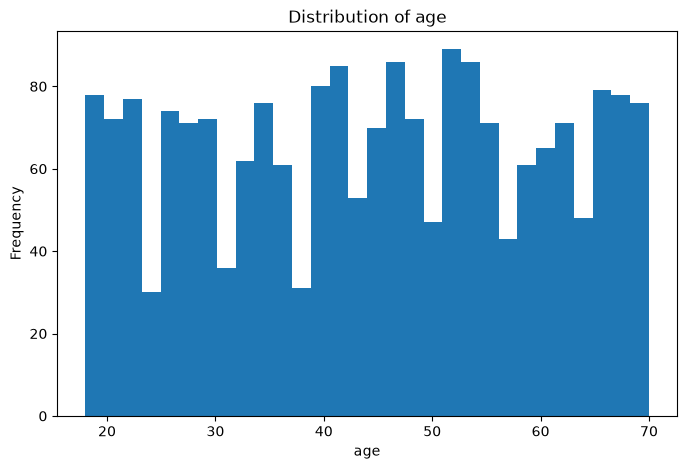

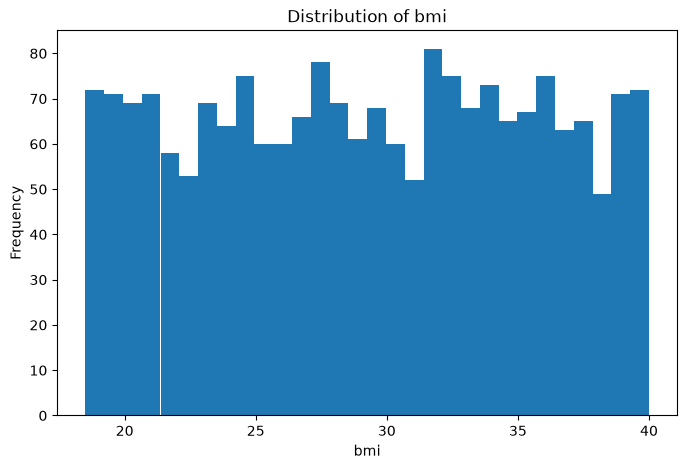

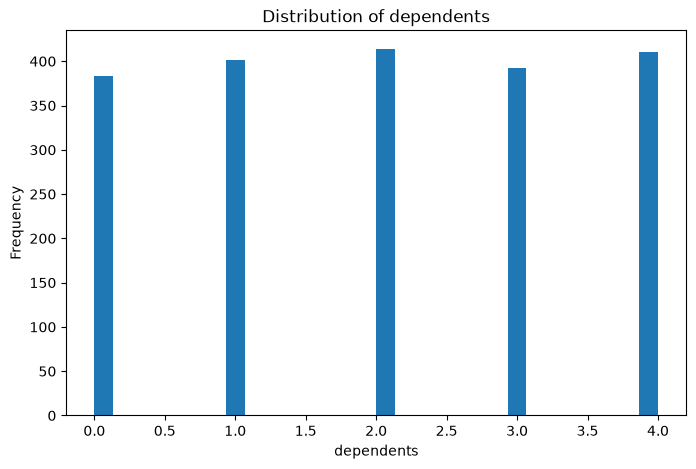

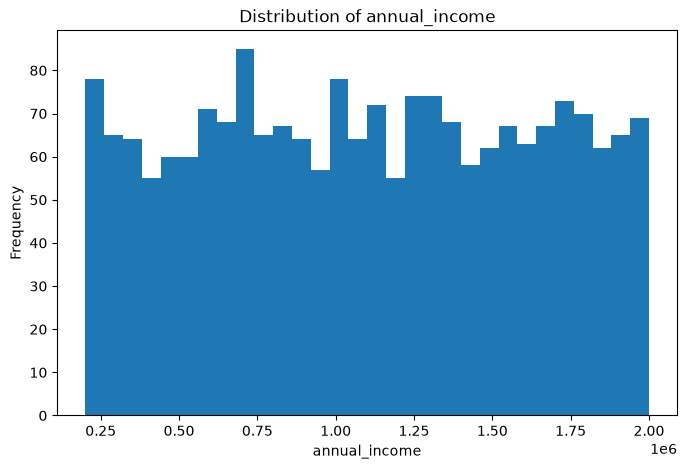

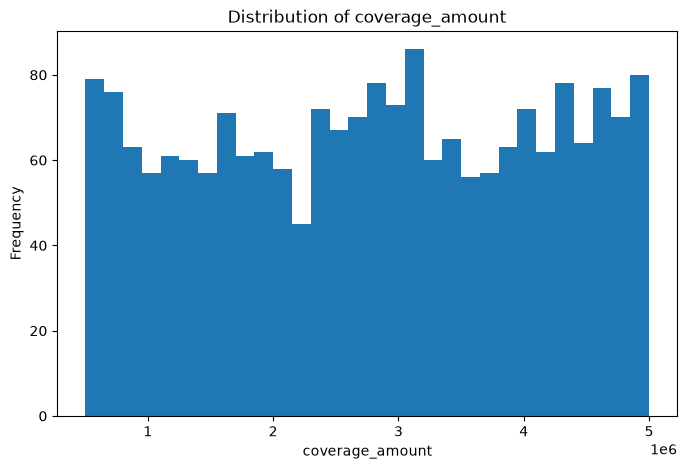

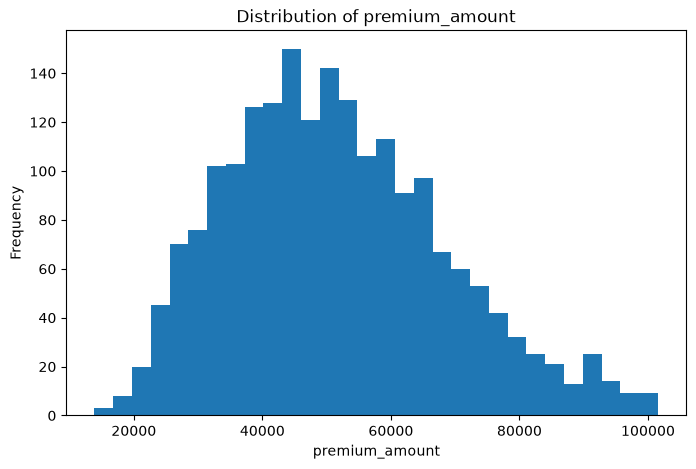

In [66]:
import matplotlib.pyplot as plt

numerical_columns = [
    'age',
    'bmi',
    'dependents',
    'annual_income',
    'coverage_amount',
    'premium_amount'
]

for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column], bins=30)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

### Distribution Insights

The distribution plots provide an overview of the numerical variables in the dataset.

- `age` is broadly distributed across the customer age range.
- `bmi` is spread across a wide range without extreme observations.
- `dependents` is a discrete variable ranging from 0 to 4.
- `annual_income` and `coverage_amount` show a wide spread of values.
- `premium_amount` is concentrated around the middle range and shows some positive skewness.

Overall, the numerical variables provide sufficient variation for further analysis and machine learning modeling.

### Distribution of Categorical Variables

Understanding the distribution of categorical variables helps identify the representation of different groups within the dataset.

We will examine smoker status, policy type, claim history, and claim risk to determine whether the categories are reasonably represented.

In [67]:
categorical_columns = [
    'smoker',
    'policy_type',
    'claim_history',
    'claim_risk'
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


smoker
smoker
No     1598
Yes     402
Name: count, dtype: int64

policy_type
policy_type
Standard         994
Basic            584
Comprehensive    422
Name: count, dtype: int64

claim_history
claim_history
3    416
1    405
4    405
0    396
2    378
Name: count, dtype: int64

claim_risk
claim_risk
0    1118
1     882
Name: count, dtype: int64


### Categorical Variable Insights

The categorical variables are reasonably represented across the dataset.

- `smoker`: Most customers are non-smokers, while a smaller proportion are smokers.
- `policy_type`: Standard policies are the most common, followed by Basic and Comprehensive policies.
- `claim_history`: All claim history categories from 0 to 4 have a similar number of observations.
- `claim_risk`: Both risk classes are well represented, with more customers belonging to the low-risk class (`0`) than the high-risk class (`1`).

Overall, there is sufficient representation across the categorical variables for further analysis and modeling.

### Categorical Variable Visualization

Bar charts are used to visualize the frequency of each category. This makes it easier to compare the representation of different customer groups and identify any noticeable class imbalance.

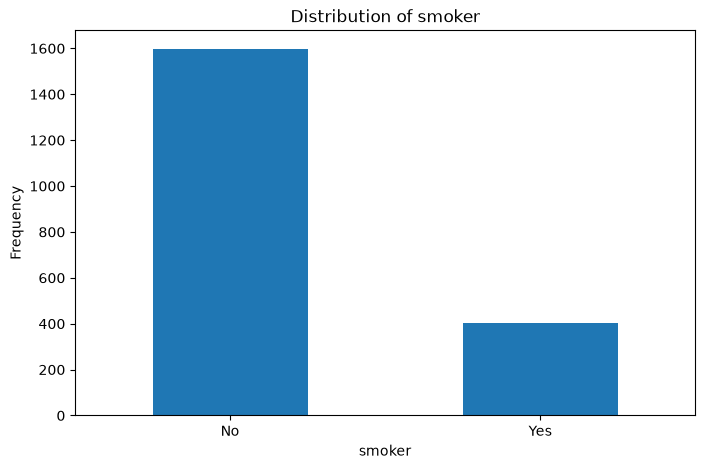

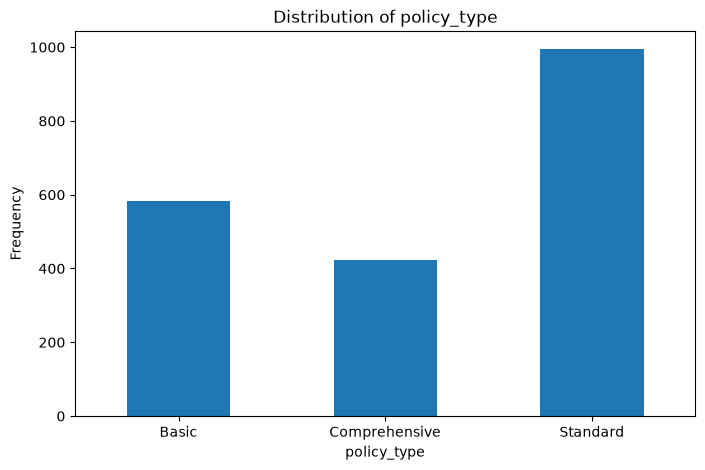

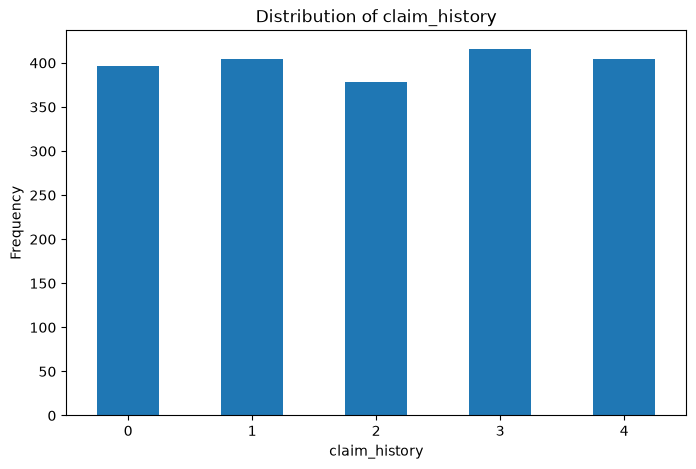

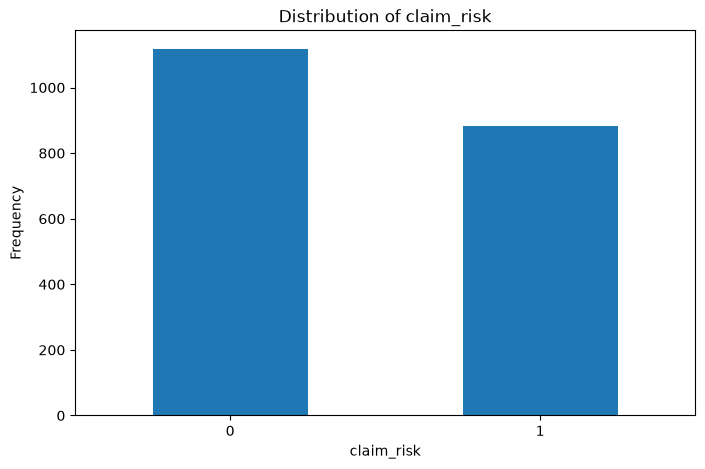

In [68]:
categorical_columns = [
    'smoker',
    'policy_type',
    'claim_history',
    'claim_risk'
]

for column in categorical_columns:
    plt.figure(figsize=(8, 5))
    df[column].value_counts().sort_index().plot(kind='bar')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.xticks(rotation=0)
    plt.show()

### Relationship Between Smoking Status and Premium Amount

Smoking status may be associated with differences in insurance premiums because smoking can represent an additional health-related risk factor.

We will compare the premium amounts of smokers and non-smokers to identify whether there is a noticeable difference between the two groups.

<Figure size 800x500 with 0 Axes>

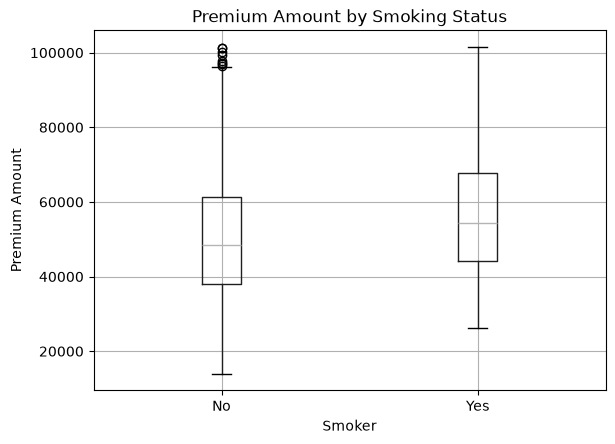

In [69]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column='premium_amount',
    by='smoker'
)

plt.title('Premium Amount by Smoking Status')
plt.suptitle('')
plt.xlabel('Smoker')
plt.ylabel('Premium Amount')

plt.show()

### Relationship Between Policy Type and Premium Amount

Different policy types may have different coverage levels and associated risks, which can influence the premium charged.

We will compare the distribution of premium amounts across Basic, Standard, and Comprehensive policies.

<Figure size 800x500 with 0 Axes>

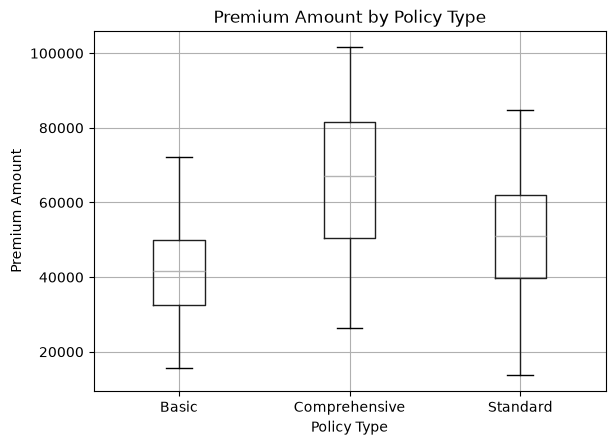

In [70]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column='premium_amount',
    by='policy_type'
)

plt.title('Premium Amount by Policy Type')
plt.suptitle('')
plt.xlabel('Policy Type')
plt.ylabel('Premium Amount')

plt.show()

### Relationship Between Coverage Amount and Premium Amount

Insurance premiums may increase as the coverage amount increases.

A scatter plot will be used to examine whether there is a relationship between coverage amount and premium amount and whether the relationship appears to be linear or non-linear.

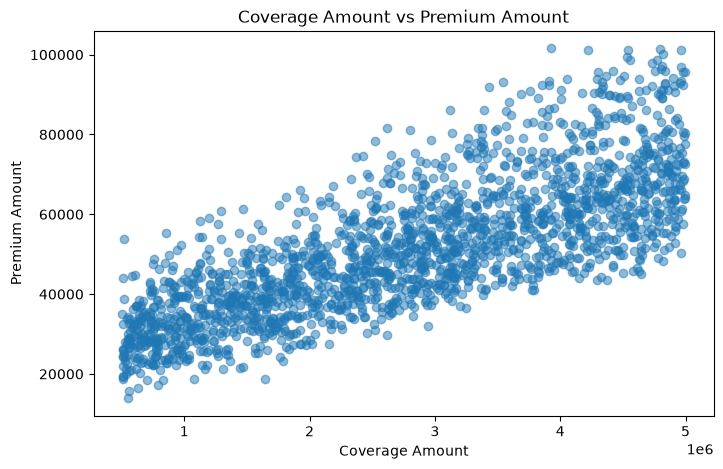

In [71]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['coverage_amount'],
    df['premium_amount'],
    alpha=0.5
)

plt.title('Coverage Amount vs Premium Amount')
plt.xlabel('Coverage Amount')
plt.ylabel('Premium Amount')

plt.show()

### Relationship Analysis Insights

The relationship analysis shows that several variables are associated with the insurance premium amount.

- **Smoking Status:** Smokers generally have higher premium amounts than non-smokers.
- **Policy Type:** Comprehensive policies have the highest median premiums, followed by Standard and Basic policies.
- **Coverage Amount:** Premium amount generally increases as coverage amount increases, indicating a positive relationship between the two variables.

These findings suggest that smoking status, policy type, and coverage amount may be important features for predicting insurance premium amounts.

### Relationship Between Smoking Status and Claim Risk

Smoking status may be associated with claim risk because smoking can represent an additional health-related risk factor.

We will compare claim risk across smokers and non-smokers to determine whether there is a noticeable difference between the two groups.

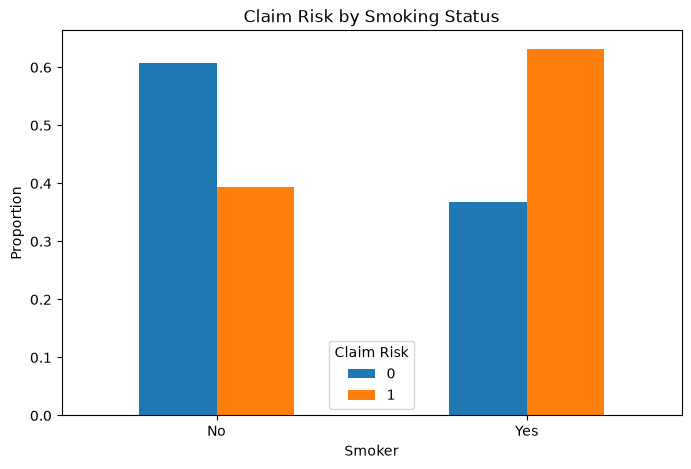

In [72]:
pd.crosstab(
    df['smoker'],
    df['claim_risk'],
    normalize='index'
).plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Claim Risk by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Claim Risk')

plt.show()

### Relationship Between Claim History and Claim Risk

Previous claim history may provide useful information about the likelihood of future insurance claims.

We will examine the relationship between claim history and claim risk to determine whether customers with different claim histories show different levels of claim risk.

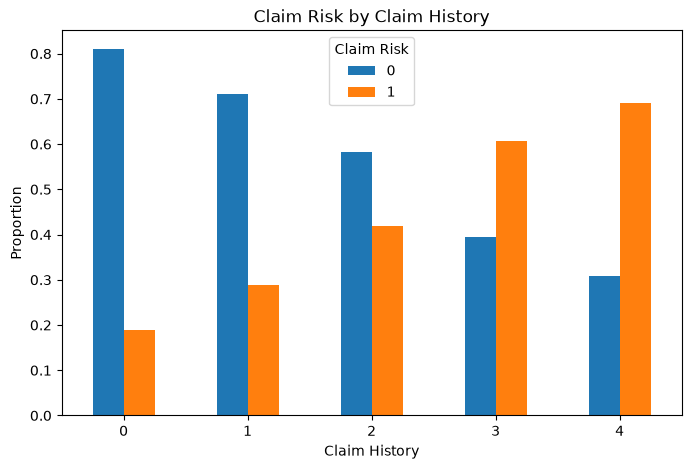

In [73]:
pd.crosstab(
    df['claim_history'],
    df['claim_risk'],
    normalize='index'
).plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Claim Risk by Claim History')
plt.xlabel('Claim History')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Claim Risk')

plt.show()

### Claim Risk Relationship Insights

The analysis shows clear differences in claim risk across smoking status and claim history.

- **Smoking Status:** Smokers have a higher proportion of high-risk (`claim_risk = 1`) customers compared with non-smokers.
- **Claim History:** The proportion of high-risk customers generally increases as previous claim history increases.

These findings suggest that smoking status and claim history may be important features for predicting claim risk. Since this is a synthetic dataset, these relationships represent patterns in the generated data and should be interpreted as associations rather than causal relationships.

### Correlation Analysis

Correlation analysis helps identify the strength and direction of relationships between numerical variables.

A correlation coefficient ranges from -1 to +1:

- Values close to **+1** indicate a strong positive relationship.
- Values close to **-1** indicate a strong negative relationship.
- Values close to **0** indicate a weak or no linear relationship.

A correlation matrix will be used to examine relationships among the numerical variables.

In [80]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,age,bmi,dependents,claim_history,annual_income,coverage_amount,claim_risk,premium_amount
age,1.000000,0.021002,-0.002938,0.045639,-0.008757,-0.014409,0.157373,0.104784
bmi,0.021002,1.000000,0.020185,0.022710,0.026784,-0.012367,0.145917,0.075487
dependents,-0.002938,0.020185,1.000000,-0.000914,-0.015662,-0.029502,0.145319,-0.019484
claim_history,0.045639,0.022710,-0.000914,1.000000,0.011075,0.000196,0.377819,0.135188
annual_income,-0.008757,0.026784,-0.015662,0.011075,1.000000,0.023971,-0.000038,0.058170
coverage_amount,-0.014409,-0.012367,-0.029502,0.000196,0.023971,1.000000,-0.010144,0.775678
claim_risk,0.157373,0.145917,0.145319,0.377819,-0.000038,-0.010144,1.000000,0.098387
premium_amount,0.104784,0.075487,-0.019484,0.135188,0.058170,0.775678,0.098387,1.000000


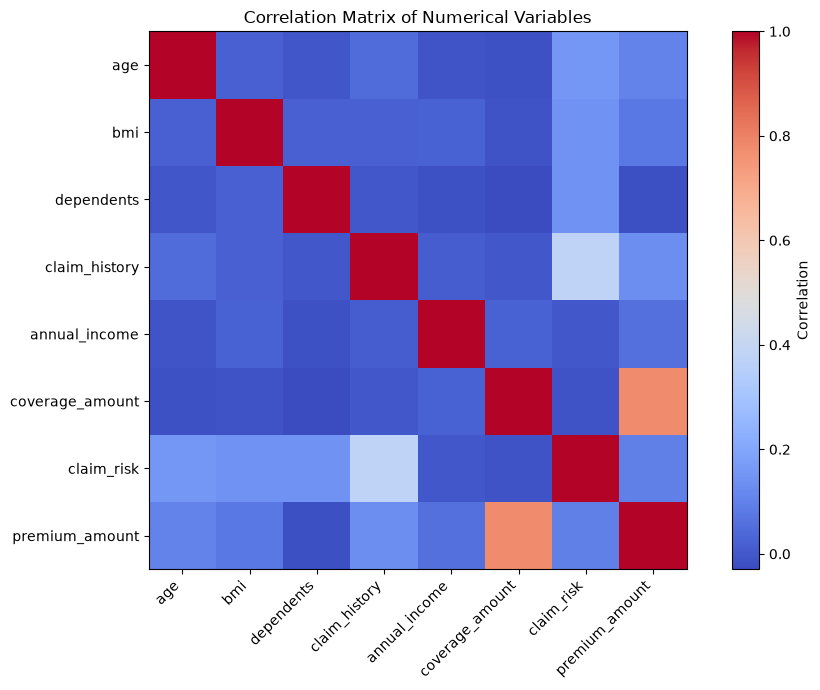

In [79]:
# Create a correlation matrix for the numerical variables
correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Correlation Matrix of Numerical Variables')

plt.tight_layout()
plt.show()

In [81]:
correlation_matrix

,age,bmi,dependents,claim_history,annual_income,coverage_amount,claim_risk,premium_amount
age,1.000000,0.021002,-0.002938,0.045639,-0.008757,-0.014409,0.157373,0.104784
bmi,0.021002,1.000000,0.020185,0.022710,0.026784,-0.012367,0.145917,0.075487
dependents,-0.002938,0.020185,1.000000,-0.000914,-0.015662,-0.029502,0.145319,-0.019484
claim_history,0.045639,0.022710,-0.000914,1.000000,0.011075,0.000196,0.377819,0.135188
annual_income,-0.008757,0.026784,-0.015662,0.011075,1.000000,0.023971,-0.000038,0.058170
coverage_amount,-0.014409,-0.012367,-0.029502,0.000196,0.023971,1.000000,-0.010144,0.775678
claim_risk,0.157373,0.145917,0.145319,0.377819,-0.000038,-0.010144,1.000000,0.098387
premium_amount,0.104784,0.075487,-0.019484,0.135188,0.058170,0.775678,0.098387,1.000000


### Correlation Analysis Insights

The correlation matrix shows the strength of linear relationships between the numerical variables.

For `premium_amount`, `coverage_amount` has the strongest positive correlation (0.776), indicating that higher coverage amounts are strongly associated with higher premiums. The remaining numerical variables show relatively weak correlations with premium amount.

For `claim_risk`, `claim_history` has the strongest positive correlation (0.378), suggesting that customers with more previous claims tend to have higher claim risk. Age, BMI, and number of dependents show weaker positive relationships with claim risk, while annual income and coverage amount have very weak correlations.

Overall, the correlation analysis identifies `coverage_amount` as an important numerical variable for premium prediction and `claim_history` as an important numerical variable for claim-risk prediction.

### Target Variable Analysis

The target variables are the outcomes that the machine learning models will predict.

- `premium_amount` is the target variable for the regression model.
- `claim_risk` is the target variable for the classification model.

Analyzing their distributions helps us understand the prediction problems and identify whether the target variables are reasonably distributed for modeling.

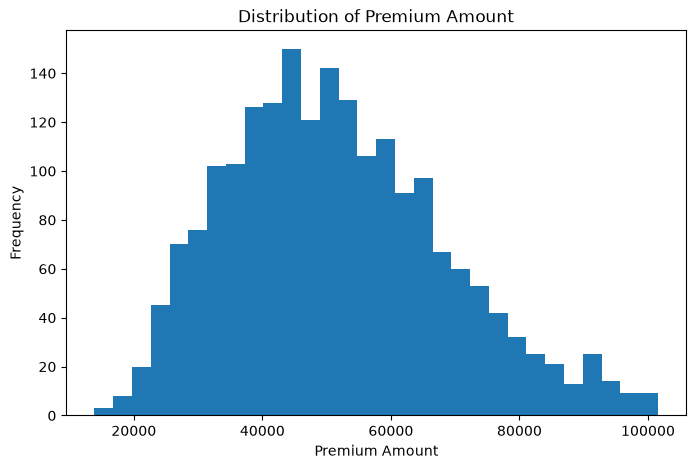

In [82]:
plt.figure(figsize=(8, 5))

plt.hist(df['premium_amount'], bins=30)

plt.title('Distribution of Premium Amount')
plt.xlabel('Premium Amount')
plt.ylabel('Frequency')

plt.show()

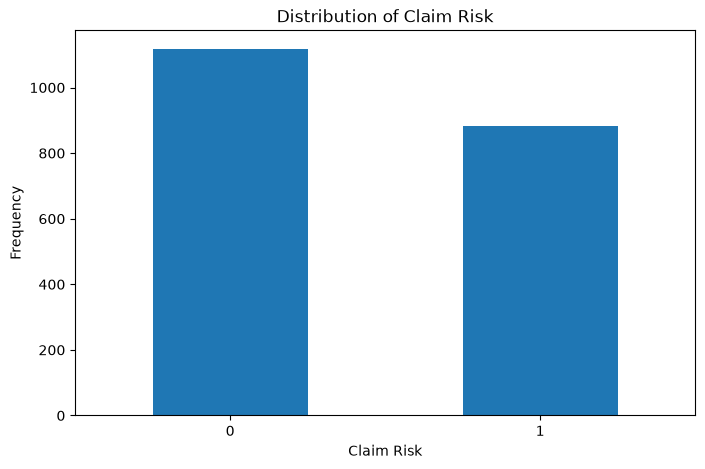

In [83]:
plt.figure(figsize=(8, 5))

df['claim_risk'].value_counts().sort_index().plot(kind='bar')

plt.title('Distribution of Claim Risk')
plt.xlabel('Claim Risk')
plt.ylabel('Frequency')
plt.xticks(rotation=0)

plt.show()

### Overall EDA Summary

The exploratory data analysis provided several important insights into the insurance dataset:

- The numerical variables show sufficient variation across the dataset.
- No major data-quality issues or missing values were identified during the initial exploration.
- The IQR analysis identified a small number of potential outliers in `annual_income` and `premium_amount`; these were retained because they represent plausible extreme observations.
- Smokers generally have higher premium amounts and higher claim risk than non-smokers.
- Comprehensive policies have higher premium amounts compared with Standard and Basic policies.
- `coverage_amount` has a strong positive correlation with `premium_amount` (0.776).
- `claim_history` has the strongest numerical relationship with `claim_risk` (0.378).
- The target variables, `premium_amount` and `claim_risk`, show suitable variation for their respective regression and classification tasks.

These findings will guide the preprocessing and machine learning stages of the project.

## Data Preprocessing

Before training the machine learning models, the dataset must be prepared for modeling.

The preprocessing stage includes checking for missing values, separating features from target variables, encoding categorical variables, scaling numerical features where necessary, and splitting the data into training and testing sets.

### Checking for Missing Values

Missing values can affect machine learning models and should be identified before model training.

We will check each column for missing values in the dataset.

In [84]:
df.isnull().sum()

age                0
bmi                0
dependents         0
smoker             0
policy_type        0
claim_history      0
annual_income      0
coverage_amount    0
claim_risk         0
premium_amount     0
dtype: int64

### Missing Value Analysis

The dataset contains no missing values across any of the variables. Therefore, no missing-value imputation or removal is required before model training.

### Separating Features and Target Variables

The dataset contains two prediction targets:

- `premium_amount` for the regression model
- `claim_risk` for the classification model

The target variable is separated from the input features for each machine learning task.

In [85]:
# Features for premium prediction
X_premium = df.drop(columns=['premium_amount', 'claim_risk'])
y_premium = df['premium_amount']

# Features for claim risk prediction
X_risk = df.drop(columns=['claim_risk', 'premium_amount'])
y_risk = df['claim_risk']

In [86]:
print("Premium Prediction:")
print("X shape:", X_premium.shape)
print("y shape:", y_premium.shape)

print("\nClaim Risk Prediction:")
print("X shape:", X_risk.shape)
print("y shape:", y_risk.shape)

Premium Prediction:
X shape: (2000, 8)
y shape: (2000,)

Claim Risk Prediction:
X shape: (2000, 8)
y shape: (2000,)


### Train-Test Split

The dataset is divided into training and testing sets to evaluate how well the machine learning models perform on unseen data.

We will use an 80:20 split:
- 80% of the data will be used for training.
- 20% will be reserved for testing.

A fixed random state is used to ensure that the results are reproducible.

In [87]:
from sklearn.model_selection import train_test_split

# Split data for premium prediction
X_train_premium, X_test_premium, y_train_premium, y_test_premium = train_test_split(
    X_premium,
    y_premium,
    test_size=0.2,
    random_state=42
)

# Split data for claim risk prediction
X_train_risk, X_test_risk, y_train_risk, y_test_risk = train_test_split(
    X_risk,
    y_risk,
    test_size=0.2,
    random_state=42
)

In [88]:
print("Premium Prediction:")
print("Training features:", X_train_premium.shape)
print("Testing features:", X_test_premium.shape)
print("Training target:", y_train_premium.shape)
print("Testing target:", y_test_premium.shape)

print("\nClaim Risk Prediction:")
print("Training features:", X_train_risk.shape)
print("Testing features:", X_test_risk.shape)
print("Training target:", y_train_risk.shape)
print("Testing target:", y_test_risk.shape)

Premium Prediction:
Training features: (1600, 8)
Testing features: (400, 8)
Training target: (1600,)
Testing target: (400,)

Claim Risk Prediction:
Training features: (1600, 8)
Testing features: (400, 8)
Training target: (1600,)
Testing target: (400,)


### Encoding Categorical Variables

Machine learning algorithms generally require numerical input features. Therefore, the categorical variables `smoker` and `policy_type` need to be converted into numerical representations.

One-hot encoding is used because these categories do not have a meaningful numerical order. Each category is represented as a separate binary feature.

In [89]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['smoker', 'policy_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough'
)

In [90]:
# Transform features for premium prediction
X_train_premium_encoded = preprocessor.fit_transform(X_train_premium)
X_test_premium_encoded = preprocessor.transform(X_test_premium)

# Transform features for claim risk prediction
X_train_risk_encoded = preprocessor.fit_transform(X_train_risk)
X_test_risk_encoded = preprocessor.transform(X_test_risk)

In [91]:
print("Premium Prediction:")
print("Training shape:", X_train_premium_encoded.shape)
print("Testing shape:", X_test_premium_encoded.shape)

print("\nClaim Risk Prediction:")
print("Training shape:", X_train_risk_encoded.shape)
print("Testing shape:", X_test_risk_encoded.shape)

Premium Prediction:
Training shape: (1600, 9)
Testing shape: (400, 9)

Claim Risk Prediction:
Training shape: (1600, 9)
Testing shape: (400, 9)


In [92]:
preprocessor.fit_transform(X_train_premium)

array([[0.000000e+00, 0.000000e+00, 1.000000e+00, ..., 2.000000e+00,
        8.013050e+05, 3.276245e+06],
       [0.000000e+00, 0.000000e+00, 0.000000e+00, ..., 1.000000e+00,
        5.162350e+05, 2.944436e+06],
       [0.000000e+00, 0.000000e+00, 1.000000e+00, ..., 1.000000e+00,
        1.641975e+06, 9.787390e+05],
       ...,
       [1.000000e+00, 1.000000e+00, 0.000000e+00, ..., 0.000000e+00,
        1.490858e+06, 2.845871e+06],
       [0.000000e+00, 0.000000e+00, 0.000000e+00, ..., 1.000000e+00,
        3.314580e+05, 1.468303e+06],
       [0.000000e+00, 0.000000e+00, 0.000000e+00, ..., 0.000000e+00,
        1.272852e+06, 4.886262e+06]], shape=(1600, 9))

In [93]:
preprocessor.fit_transform(X_train_risk)

array([[0.000000e+00, 0.000000e+00, 1.000000e+00, ..., 2.000000e+00,
        8.013050e+05, 3.276245e+06],
       [0.000000e+00, 0.000000e+00, 0.000000e+00, ..., 1.000000e+00,
        5.162350e+05, 2.944436e+06],
       [0.000000e+00, 0.000000e+00, 1.000000e+00, ..., 1.000000e+00,
        1.641975e+06, 9.787390e+05],
       ...,
       [1.000000e+00, 1.000000e+00, 0.000000e+00, ..., 0.000000e+00,
        1.490858e+06, 2.845871e+06],
       [0.000000e+00, 0.000000e+00, 0.000000e+00, ..., 1.000000e+00,
        3.314580e+05, 1.468303e+06],
       [0.000000e+00, 0.000000e+00, 0.000000e+00, ..., 0.000000e+00,
        1.272852e+06, 4.886262e+06]], shape=(1600, 9))

### Feature Scaling

The numerical features have different ranges and units. For example, age and BMI have relatively small values, while annual income and coverage amount have much larger values.

Standardization is used to transform numerical features so that they have a mean close to 0 and a standard deviation close to 1.

The scaler will be fitted only on the training data and then applied to the testing data to prevent data leakage.

In [94]:
from sklearn.preprocessing import StandardScaler

numerical_features = [
    'age',
    'bmi',
    'dependents',
    'claim_history',
    'annual_income',
    'coverage_amount'
]

In [ ]:
#Preprocessing pipeline for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

In [96]:
# Premium prediction
X_train_premium_processed = preprocessor.fit_transform(X_train_premium)
X_test_premium_processed = preprocessor.transform(X_test_premium)

# Claim risk prediction
X_train_risk_processed = preprocessor.fit_transform(X_train_risk)
X_test_risk_processed = preprocessor.transform(X_test_risk)

In [97]:
print("Premium Prediction:")
print("Training shape:", X_train_premium_processed.shape)
print("Testing shape:", X_test_premium_processed.shape)

print("\nClaim Risk Prediction:")
print("Training shape:", X_train_risk_processed.shape)
print("Testing shape:", X_test_risk_processed.shape)

Premium Prediction:
Training shape: (1600, 9)
Testing shape: (400, 9)

Claim Risk Prediction:
Training shape: (1600, 9)
Testing shape: (400, 9)


## Machine Learning — Premium Prediction

The first machine learning task is to predict the insurance `premium_amount`.

Since `premium_amount` is a continuous numerical variable, this is a regression problem.

We will first train a Linear Regression model as a baseline and evaluate its performance using appropriate regression metrics.

### Linear Regression

Linear Regression is used as the baseline regression model. It attempts to model the relationship between the input features and the premium amount by fitting a linear relationship between them.

In [98]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_model = LinearRegression()

linear_model.fit(
    X_train_premium_processed,
    y_train_premium
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 1859.08, 1610.82, -129.87,..., 8156.56,25513.28, 9952.68]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.966e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[41.49,40.9 ,40.62,...,22.62,16.1 ,12.26]"


In [100]:
y_pred_linear = linear_model.predict(X_test_premium_processed)

### Regression Model Evaluation

The Linear Regression model is evaluated using three metrics:

- **Mean Absolute Error (MAE):** Measures the average absolute prediction error.
- **Root Mean Squared Error (RMSE):** Measures the magnitude of prediction errors while giving greater weight to larger errors.
- **R² Score:** Measures the proportion of variance in the target variable explained by the model.

For MAE and RMSE, lower values indicate better performance, while a higher R² score indicates better performance.

In [101]:
mae_linear = mean_absolute_error(y_test_premium, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test_premium, y_pred_linear)
)

r2_linear = r2_score(
    y_test_premium,
    y_pred_linear
)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Results
-------------------------
MAE : 3179.6295688447494
RMSE: 4042.5145456234545
R²  : 0.938411833228175


### Linear Regression Results

The Linear Regression model achieved an MAE of approximately ₹3,179.63, an RMSE of approximately ₹4,042.51, and an R² score of 0.9384.

The R² score indicates that the model explains approximately 93.84% of the variation in premium amount. The relatively low MAE compared with the overall premium range also indicates good predictive performance.

Linear Regression therefore provides a strong baseline for the premium prediction task. More advanced regression models will be trained to determine whether this performance can be improved.

### Random Forest Regression

Random Forest Regression is a tree-based ensemble model that combines predictions from multiple decision trees.

Unlike Linear Regression, Random Forest can capture non-linear relationships and interactions between features. It will be trained and compared with the Linear Regression baseline to determine whether it provides better premium predictions.

In [102]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(
    X_train_premium_processed,
    y_train_premium
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [103]:
y_pred_rf = random_forest_model.predict(
    X_test_premium_processed
)

In [104]:
mae_rf = mean_absolute_error(
    y_test_premium,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(y_test_premium, y_pred_rf)
)

r2_rf = r2_score(
    y_test_premium,
    y_pred_rf
)

print("Random Forest Regression Results")
print("--------------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression Results
--------------------------------
MAE : 2836.2159330000018
RMSE: 3570.4456578270683
R²  : 0.9519560230846764


### Random Forest Regression Results

The Random Forest Regression model achieved an MAE of approximately ₹2,836.22, an RMSE of approximately ₹3,570.45, and an R² score of 0.9520.

Compared with the Linear Regression baseline, Random Forest achieved lower MAE and RMSE and a higher R² score. This indicates that Random Forest provides better predictive performance for premium amount in this dataset.

The improved performance suggests that non-linear relationships and interactions between features may contribute to premium prediction.

### Regression Model Comparison

The performance of the regression models is compared using MAE, RMSE, and R².

Lower MAE and RMSE indicate smaller prediction errors, while a higher R² score indicates better explanatory and predictive performance.

In [105]:
regression_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regression'
    ],
    'MAE': [
        mae_linear,
        mae_rf
    ],
    'RMSE': [
        rmse_linear,
        rmse_rf
    ],
    'R2 Score': [
        r2_linear,
        r2_rf
    ]
})

regression_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3179.629569,4042.514546,0.938412
1,Random Forest Regression,2836.215933,3570.445658,0.951956


### Gradient Boosting Regression

Gradient Boosting Regression is an ensemble learning method that builds multiple decision trees sequentially. Each new tree attempts to reduce the errors made by the previous trees.

It can capture non-linear relationships between features and may provide improved predictive performance compared with the baseline models.

In [106]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(
    X_train_premium_processed,
    y_train_premium
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [107]:
y_pred_gb = gradient_boosting_model.predict(
    X_test_premium_processed
)

In [108]:
mae_gb = mean_absolute_error(
    y_test_premium,
    y_pred_gb
)

rmse_gb = np.sqrt(
    mean_squared_error(y_test_premium, y_pred_gb)
)

r2_gb = r2_score(
    y_test_premium,
    y_pred_gb
)

print("Gradient Boosting Regression Results")
print("-------------------------------------")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting Regression Results
-------------------------------------
MAE : 2614.9784690552997
RMSE: 3298.8870822267518
R²  : 0.9589862957640118


### Regression Model Comparison Results

Three regression models were evaluated: Linear Regression, Random Forest Regression, and Gradient Boosting Regression.

Gradient Boosting achieved the best overall performance, with an MAE of approximately ₹2,614.98, an RMSE of approximately ₹3,298.89, and an R² score of 0.9590.

Compared with the other models, Gradient Boosting produced the lowest prediction errors and the highest R² score. Therefore, Gradient Boosting is the best-performing regression model among the models evaluated for predicting insurance premium amount.

In [109]:
regression_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest Regression',
        'Gradient Boosting Regression'
    ],
    'MAE': [
        mae_linear,
        mae_rf,
        mae_gb
    ],
    'RMSE': [
        rmse_linear,
        rmse_rf,
        rmse_gb
    ],
    'R2 Score': [
        r2_linear,
        r2_rf,
        r2_gb
    ]
})

regression_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3179.629569,4042.514546,0.938412
1,Random Forest Regression,2836.215933,3570.445658,0.951956
2,Gradient Boosting Regression,2614.978469,3298.887082,0.958986


### Feature Importance for Premium Prediction

Feature importance helps identify which input variables contribute most to the predictions made by the Gradient Boosting model.

This analysis provides additional insight into the factors that are most influential in predicting insurance premium amounts.

In [110]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gradient_boosting_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
5,num__coverage_amount,0.637388
7,cat__policy_type_Comprehensive,0.220748
8,cat__policy_type_Standard,0.063527
6,cat__smoker_Yes,0.033856
3,num__claim_history,0.017280
0,num__age,0.013581
1,num__bmi,0.010960
4,num__annual_income,0.002436
2,num__dependents,0.000223


### Feature Importance Insights

The Gradient Boosting model indicates that `coverage_amount` is the most influential feature for predicting `premium_amount`, with a feature importance of approximately 0.637.

Policy type is the next most influential factor, particularly the Comprehensive category. Smoking status also contributes to the model, although its importance is considerably lower than coverage amount and policy type.

Age, BMI, claim history, annual income, and dependents have relatively smaller feature importance values in this model.

These results are consistent with the earlier EDA, where `coverage_amount` showed a strong positive correlation with `premium_amount`. The feature importance analysis provides additional evidence that coverage amount is a key predictor of premium amount in this synthetic dataset.

Feature importance indicates how much the model relies on each feature for prediction; it should not be interpreted as proof of causation.

## Machine Learning — Claim Risk Prediction

The second machine learning task is to predict `claim_risk`.

Since `claim_risk` is a binary target containing two classes (0 and 1), this is a binary classification problem.

Logistic Regression will first be used as a baseline classification model. Additional classification models will then be trained and compared to determine which model performs best.

In [111]:
y_train_risk.value_counts()

claim_risk
0    881
1    719
Name: count, dtype: int64

In [112]:
y_train_risk.value_counts(normalize=True)

claim_risk
0    0.550625
1    0.449375
Name: proportion, dtype: float64

### Logistic Regression

Logistic Regression is used as the baseline classification model for predicting claim risk.

Since `claim_risk` contains two classes (0 and 1), Logistic Regression estimates the probability of an observation belonging to the high-risk class and converts this probability into a classification outcome.

In [113]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_risk_processed,
    y_train_risk
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [114]:
y_pred_logistic = logistic_model.predict(
    X_test_risk_processed
)

### Classification Model Evaluation

The Logistic Regression model will be evaluated using accuracy, precision, recall, and F1-score.

- **Accuracy:** Proportion of all predictions that are correct.
- **Precision:** Proportion of predicted high-risk cases that are actually high-risk.
- **Recall:** Proportion of actual high-risk cases correctly identified by the model.
- **F1-score:** Harmonic mean of precision and recall, providing a balance between the two metrics.

A confusion matrix will also be used to examine the model's correct and incorrect predictions by class.

In [115]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy_logistic = accuracy_score(
    y_test_risk,
    y_pred_logistic
)

precision_logistic = precision_score(
    y_test_risk,
    y_pred_logistic
)

recall_logistic = recall_score(
    y_test_risk,
    y_pred_logistic
)

f1_logistic = f1_score(
    y_test_risk,
    y_pred_logistic
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_logistic)
print("Precision:", precision_logistic)
print("Recall   :", recall_logistic)
print("F1 Score :", f1_logistic)

Logistic Regression Results
---------------------------
Accuracy : 0.7225
Precision: 0.6566265060240963
Recall   : 0.6687116564417178
F1 Score : 0.662613981762918


In [116]:
cm_logistic = confusion_matrix(
    y_test_risk,
    y_pred_logistic
)

print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[180  57]
 [ 54 109]]


### Logistic Regression Results

The Logistic Regression model achieved an accuracy of 72.25%, a precision of 65.66%, a recall of 66.87%, and an F1-score of 66.26%.

The confusion matrix shows that the model correctly classified 180 low-risk customers and 109 high-risk customers. However, 54 high-risk customers were incorrectly classified as low-risk.

These results provide a baseline for the claim-risk classification task. Additional classification models will be evaluated to determine whether predictive performance can be improved.

### Random Forest Classification

Random Forest Classifier is an ensemble learning algorithm that combines multiple decision trees to make classification predictions.

It can capture non-linear relationships and interactions between features and will be compared with Logistic Regression to determine whether it improves claim-risk prediction.

In [117]:
from sklearn.ensemble import RandomForestClassifier

random_forest_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

random_forest_classifier.fit(
    X_train_risk_processed,
    y_train_risk
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [118]:
y_pred_rf_classifier = random_forest_classifier.predict(
    X_test_risk_processed
)

In [119]:
accuracy_rf = accuracy_score(
    y_test_risk,
    y_pred_rf_classifier
)

precision_rf = precision_score(
    y_test_risk,
    y_pred_rf_classifier
)

recall_rf = recall_score(
    y_test_risk,
    y_pred_rf_classifier
)

f1_rf = f1_score(
    y_test_risk,
    y_pred_rf_classifier
)

print("Random Forest Classification Results")
print("------------------------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Random Forest Classification Results
------------------------------------
Accuracy : 0.725
Precision: 0.6666666666666666
Recall   : 0.6503067484662577
F1 Score : 0.6583850931677019


In [120]:
cm_rf = confusion_matrix(
    y_test_risk,
    y_pred_rf_classifier
)

print("Confusion Matrix:")
print(cm_rf)

Confusion Matrix:
[[184  53]
 [ 57 106]]


### Random Forest Classification Results

The Random Forest Classifier achieved an accuracy of 72.50%, precision of 66.67%, recall of 65.03%, and an F1-score of 65.84%.

Compared with Logistic Regression, Random Forest achieved slightly higher accuracy and precision but lower recall and F1-score. Therefore, it does not provide an overall improvement over the Logistic Regression baseline.

Since identifying high-risk customers is important, recall and F1-score will also be considered when selecting the final classification model.

### Gradient Boosting Classification

Gradient Boosting Classifier is an ensemble learning method that builds decision trees sequentially, with each new tree attempting to correct the errors of the previous trees.

It can capture non-linear relationships between features and will be evaluated to determine whether it improves claim-risk prediction compared with Logistic Regression and Random Forest.

In [121]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_classifier = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_classifier.fit(
    X_train_risk_processed,
    y_train_risk
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i

In [122]:
y_pred_gb_classifier = gradient_boosting_classifier.predict(
    X_test_risk_processed
)

In [123]:
accuracy_gb = accuracy_score(
    y_test_risk,
    y_pred_gb_classifier
)

precision_gb = precision_score(
    y_test_risk,
    y_pred_gb_classifier
)

recall_gb = recall_score(
    y_test_risk,
    y_pred_gb_classifier
)

f1_gb = f1_score(
    y_test_risk,
    y_pred_gb_classifier
)

print("Gradient Boosting Classification Results")
print("-----------------------------------------")
print("Accuracy :", accuracy_gb)
print("Precision:", precision_gb)
print("Recall   :", recall_gb)
print("F1 Score :", f1_gb)

Gradient Boosting Classification Results
-----------------------------------------
Accuracy : 0.7125
Precision: 0.65
Recall   : 0.6380368098159509
F1 Score : 0.6439628482972136


In [124]:
cm_gb = confusion_matrix(
    y_test_risk,
    y_pred_gb_classifier
)

print("Confusion Matrix:")
print(cm_gb)

Confusion Matrix:
[[181  56]
 [ 59 104]]


### Classification Model Comparison Results

Three classification models were evaluated: Logistic Regression, Random Forest Classifier, and Gradient Boosting Classifier.

Random Forest achieved the highest accuracy (72.50%) and precision (66.67%). However, Logistic Regression achieved the highest recall (66.87%) and F1-score (66.26%).

Since identifying high-risk customers is an important objective of the classification task, recall and F1-score are given greater consideration than accuracy alone.

Therefore, Logistic Regression is selected as the final classification model for claim-risk prediction.

In [125]:
classification_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest Classifier',
        'Gradient Boosting Classifier'
    ],
    'Accuracy': [
        accuracy_logistic,
        accuracy_rf,
        accuracy_gb
    ],
    'Precision': [
        precision_logistic,
        precision_rf,
        precision_gb
    ],
    'Recall': [
        recall_logistic,
        recall_rf,
        recall_gb
    ],
    'F1 Score': [
        f1_logistic,
        f1_rf,
        f1_gb
    ]
})

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7225,0.656627,0.668712,0.662614
1,Random Forest Classifier,0.7250,0.666667,0.650307,0.658385
2,Gradient Boosting Classifier,0.7125,0.650000,0.638037,0.643963


In [126]:
feature_names_risk = preprocessor.get_feature_names_out()

risk_coefficients = pd.DataFrame({
    'Feature': feature_names_risk,
    'Coefficient': logistic_model.coef_[0]
})

risk_coefficients['Absolute_Coefficient'] = (
    risk_coefficients['Coefficient'].abs()
)

risk_coefficients = risk_coefficients.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

risk_coefficients

,Feature,Coefficient,Absolute_Coefficient
6,cat__smoker_Yes,1.270908,1.270908
3,num__claim_history,0.932331,0.932331
2,num__dependents,0.395619,0.395619
0,num__age,0.370661,0.370661
1,num__bmi,0.331547,0.331547
7,cat__policy_type_Comprehensive,-0.169071,0.169071
8,cat__policy_type_Standard,0.077625,0.077625
4,num__annual_income,0.021171,0.021171
5,num__coverage_amount,-0.010532,0.010532


### Logistic Regression Coefficient Analysis

The Logistic Regression coefficients provide insight into the features associated with predicted claim risk.

`smoker_Yes` has the largest positive coefficient (1.271), followed by `claim_history` (0.932). This indicates that these features have the strongest positive association with the model's prediction of high claim risk.

Dependents, age, and BMI also have positive coefficients, although their influence is smaller.

The `policy_type_Comprehensive` feature has a negative coefficient (-0.169), while `policy_type_Standard` has a small positive coefficient (0.078). Annual income and coverage amount have relatively small coefficients, indicating limited influence on the model's predictions compared with the other features.

Overall, the coefficient analysis is consistent with the EDA findings, particularly the strong relationship observed between smoking status, claim history, and claim risk.

These coefficients describe associations learned by the model and should not be interpreted as causal effects.

In [127]:
print(classification_report(
    y_test_risk,
    y_pred_logistic,
    target_names=['Low Risk', 'High Risk']
))

              precision    recall  f1-score   support

    Low Risk       0.77      0.76      0.76       237
   High Risk       0.66      0.67      0.66       163

    accuracy                           0.72       400
   macro avg       0.71      0.71      0.71       400
weighted avg       0.72      0.72      0.72       400



### Final Classification Report

The Logistic Regression model achieved an overall accuracy of 72% on the test set.

For the high-risk class, the model achieved a precision of 0.66, recall of 0.67, and F1-score of 0.66. This means the model correctly identifies approximately 67% of the customers who actually belong to the high-risk class.

The model performs somewhat better for the Low Risk class, with a precision of 0.77, recall of 0.76, and F1-score of 0.76.

Overall, the classification model provides a reasonable baseline for identifying claim risk in the synthetic dataset.

### ROC-AUC Evaluation

ROC-AUC is used to evaluate how well the Logistic Regression model distinguishes between low-risk and high-risk customers across different classification thresholds.

A higher ROC-AUC indicates better ability to distinguish between the two classes.

In [128]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob_logistic = logistic_model.predict_proba(
    X_test_risk_processed
)[:, 1]

roc_auc = roc_auc_score(
    y_test_risk,
    y_prob_logistic
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8023090264295515


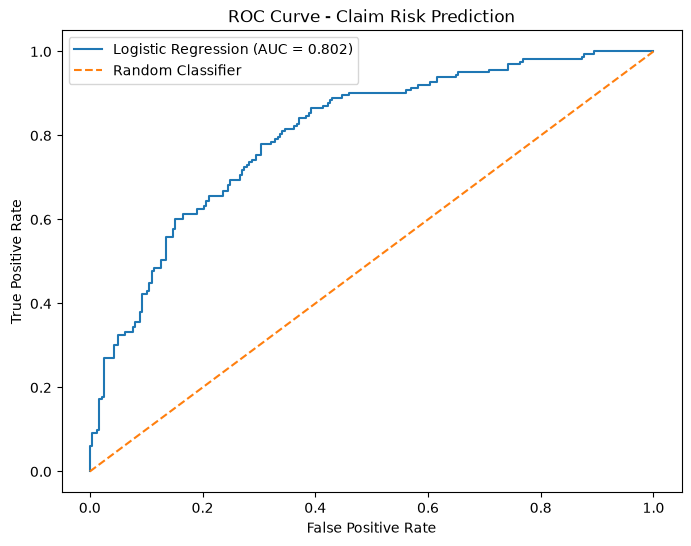

In [129]:
fpr, tpr, thresholds = roc_curve(
    y_test_risk,
    y_prob_logistic
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Claim Risk Prediction')
plt.legend()

plt.show()

### ROC-AUC Result

The Logistic Regression model achieved a ROC-AUC score of 0.8023.

This indicates that the model has a good ability to distinguish between low-risk and high-risk customers. The ROC-AUC score also provides a threshold-independent measure of classification performance, complementing the accuracy, precision, recall, and F1-score results.

Overall, the model demonstrates reasonable predictive capability for claim-risk classification in the synthetic dataset.

## Final Evaluation — Premium Prediction

The Gradient Boosting Regression model achieved the best performance among the evaluated regression models.

To further evaluate its predictions, an Actual vs Predicted plot is used. This visualization compares the actual premium amounts with the values predicted by the model.

If the predictions are accurate, the points should lie close to the diagonal reference line.

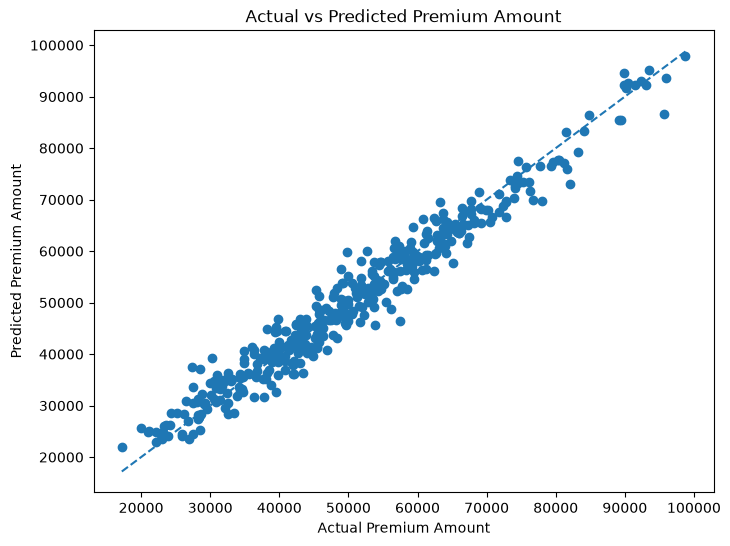

In [130]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_premium,
    y_pred_gb
)

plt.plot(
    [y_test_premium.min(), y_test_premium.max()],
    [y_test_premium.min(), y_test_premium.max()],
    linestyle='--'
)

plt.xlabel('Actual Premium Amount')
plt.ylabel('Predicted Premium Amount')
plt.title('Actual vs Predicted Premium Amount')

plt.show()

### Actual vs Predicted Analysis

The Actual vs Predicted plot shows that most predictions are located close to the diagonal reference line. This indicates that the Gradient Boosting Regression model produces predictions that are generally close to the actual premium amounts.

A small number of observations deviate further from the diagonal, representing larger prediction errors. Overall, the plot supports the strong performance indicated by the regression metrics, particularly the R² score of 0.9590.

### Residual Analysis

Residual analysis is used to examine the errors made by the regression model.

A residual is calculated as the difference between the actual and predicted premium amounts:

Residual = Actual Premium − Predicted Premium

Ideally, residuals should be randomly distributed around zero without a clear pattern. This indicates that the model has captured the main relationships in the data.

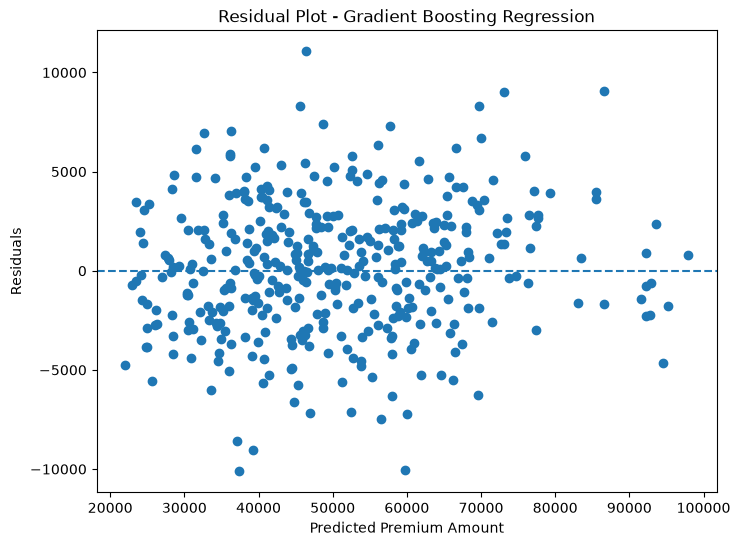

In [131]:
residuals = y_test_premium - y_pred_gb

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_gb,
    residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Premium Amount')
plt.ylabel('Residuals')
plt.title('Residual Plot - Gradient Boosting Regression')

plt.show()

In [132]:
print("Mean Residual:", residuals.mean())

Mean Residual: 195.64742855065796


### Residual Analysis Results

The residual plot shows that the residuals are generally scattered around the zero line without a strong systematic pattern. This indicates that the Gradient Boosting Regression model has captured the main relationships in the data reasonably well.

The mean residual is approximately ₹195.65, which is relatively small compared with the overall range of premium amounts. The positive value indicates a slight tendency of the model to underpredict premium amounts on average.

Overall, the residual analysis supports the strong performance of the Gradient Boosting Regression model, with no major systematic error pattern observed.

## Saving the Final Models

The best-performing models are saved so that they can be reused later without retraining them.

- Gradient Boosting Regression is saved for premium amount prediction.
- Logistic Regression is saved for claim-risk prediction.
- The preprocessing pipeline is also saved to ensure that new input data is transformed in the same way as the training data.

In [133]:
import joblib

joblib.dump(
    gradient_boosting_model,
    "premium_prediction_model.pkl"
)

joblib.dump(
    logistic_model,
    "claim_risk_model.pkl"
)

joblib.dump(
    preprocessor,
    "preprocessor.pkl"
)

print("Models and preprocessor saved successfully.")

Models and preprocessor saved successfully.


In [134]:
premium_model_loaded = joblib.load(
    "premium_prediction_model.pkl"
)

claim_risk_model_loaded = joblib.load(
    "claim_risk_model.pkl"
)

preprocessor_loaded = joblib.load(
    "preprocessor.pkl"
)

print("All models and preprocessor loaded successfully.")

All models and preprocessor loaded successfully.


### Testing the Prediction Pipeline

Before deploying the models, a sample customer is used to verify that the saved preprocessing pipeline and trained models can generate predictions for new input data.

In [135]:
sample_customer = pd.DataFrame({
    'age': [35],
    'bmi': [27.5],
    'dependents': [2],
    'smoker': ['No'],
    'policy_type': ['Standard'],
    'claim_history': [1],
    'annual_income': [1500000],
    'coverage_amount': [2500000]
})

sample_customer

,age,bmi,dependents,smoker,policy_type,claim_history,annual_income,coverage_amount
0,35,27.5,2,No,Standard,1,1500000,2500000


In [136]:
sample_customer_processed = preprocessor_loaded.transform(
    sample_customer
)

In [137]:
predicted_premium = premium_model_loaded.predict(
    sample_customer_processed
)[0]

predicted_claim_risk = claim_risk_model_loaded.predict(
    sample_customer_processed
)[0]

print("Predicted Premium Amount: ₹", round(predicted_premium, 2))

if predicted_claim_risk == 1:
    print("Predicted Claim Risk: High Risk")
else:
    print("Predicted Claim Risk: Low Risk")

Predicted Premium Amount: ₹ 43402.03
Predicted Claim Risk: Low Risk
